# Female Individual Animal Survival Data — Summary Stats
**Source:** CEBS / NIEHS — Cell Phone Radiation: CDMA study (accession 3800_7854)

In [1]:
import pandas as pd
from pathlib import Path

DATA_FILE = Path("../data/TR-595_Technical_Report_Pathology_Tables_and_Curves/2010556_Female_Individual_Animal_Survival_Data.xls")

# The .xls file is actually HTML — read via read_html
tables = pd.read_html(DATA_FILE)
meta = tables[0]
df = tables[1]

print("Study metadata:")
display(meta)
print(f"\nMain table shape: {df.shape}")
df.head()

Study metadata:


,0,1
0,Chemical Name:,Cell Phone Radiation: CDMA
1,CASRN:,"=""CELLPRADCDMA"""
2,Study Number:,C20105B
3,Exposure Route:,Whole Body Exposure
4,TDMS Number:,2010556
5,Sex:,Female
6,Strain and Species:,HSD Rats



Main table shape: (419, 6)


,Animal Number,Cage Number,Days on Study,Treatment,Removal Reason,Week of Removal
0,606,606,93,Vehicle Control,Scheduled Sacrifice,14
1,607,607,550,Vehicle Control,Moribund Sacrifice,79
2,608,608,662,Vehicle Control,Moribund Sacrifice,95
3,609,609,739,Vehicle Control,Terminal Sacrifice,106
4,610,610,738,Vehicle Control,Terminal Sacrifice,106


## 1. Column types & missing values

In [2]:
info = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.notna().sum(),
    "null": df.isna().sum(),
    "null_%": (df.isna().mean() * 100).round(1),
})
display(info)

,dtype,non_null,null,null_%
Animal Number,int64,419,0,0.0
Cage Number,int64,419,0,0.0
Days on Study,int64,419,0,0.0
Treatment,str,419,0,0.0
Removal Reason,str,419,0,0.0
Week of Removal,int64,419,0,0.0


## 2. Numeric summary — Days on Study & Week of Removal

In [3]:
display(df[["Days on Study", "Week of Removal"]].describe().round(2))

,Days on Study,Week of Removal
count,419.00,419.00
mean,592.91,85.16
std,227.84,32.51
min,16.00,3.00
25%,545.00,78.00
50%,724.00,104.00
75%,740.00,106.00
max,745.00,107.00


## 3. Animal counts by Treatment group

In [4]:
display(df["Treatment"].value_counts().rename_axis("Treatment").reset_index(name="Count"))

,Treatment,Count
0,Vehicle Control,105
1,3.0,105
2,6.0,105
3,1.5,104


## 4. Removal reasons

In [5]:
display(df["Removal Reason"].value_counts().rename_axis("Removal Reason").reset_index(name="Count"))

,Removal Reason,Count
0,Terminal Sacrifice,202
1,Moribund Sacrifice,106
2,Scheduled Sacrifice,60
3,Natural Death,50
4,Accidentally Killed,1


## 5. Days on Study by Treatment — per-group stats

In [6]:
display(
    df.groupby("Treatment")["Days on Study"]
    .agg(n="count", mean="mean", median="median", std="std", min="min", max="max")
    .round(1)
    .sort_values("mean", ascending=False)
)

,n,mean,median,std,min,max
Treatment,,,,,,
6.0,105,616.0,738.0,225.0,93,745
1.5,104,590.8,711.0,229.8,93,744
3.0,105,585.2,711.0,232.0,16,745
Vehicle Control,105,579.6,707.0,226.1,93,745


## 6. Early mortality (removed before week 105 for non-scheduled reasons)

In [7]:
early = df[
    ~df["Removal Reason"].isin(["Terminal Sacrifice", "Scheduled Sacrifice"])
    & (df["Week of Removal"] < 105)
]

print(f"Early/non-scheduled removals: {len(early)} of {len(df)} ({len(early)/len(df)*100:.1f}%)\n")

display(
    early.groupby("Treatment")
    .agg(
        early_deaths=("Animal Number", "count"),
        median_day=("Days on Study", "median"),
    )
    .sort_index()
)

Early/non-scheduled removals: 152 of 419 (36.3%)



,early_deaths,median_day
Treatment,,
1.5,41,649.0
3.0,40,612.5
6.0,29,651.0
Vehicle Control,42,571.5


## 7. Kaplan-Meier Survival Curves by Treatment

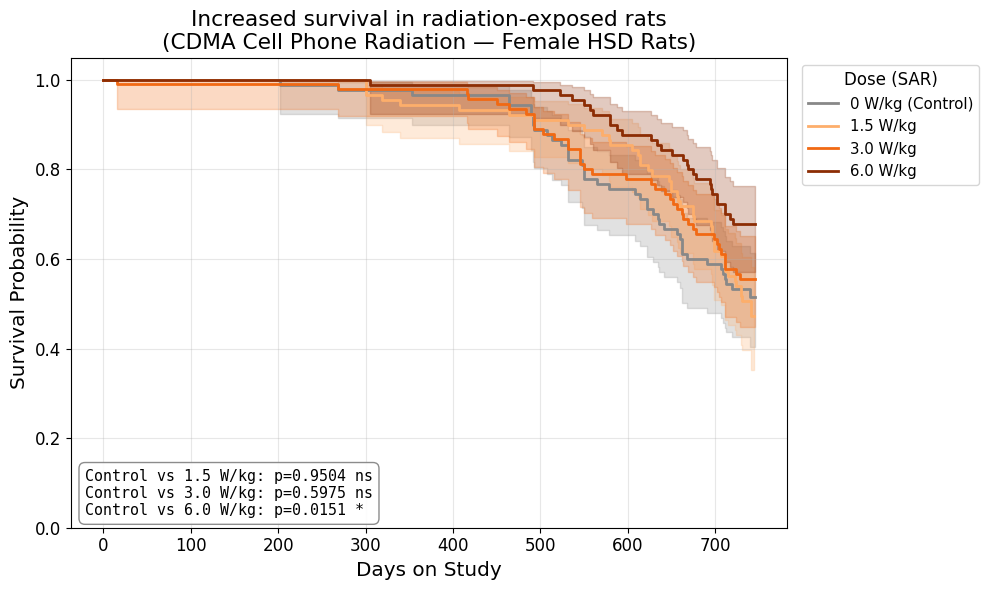

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

# Dose mapping and event indicator
dose_map = {"Vehicle Control": 0, "1.5": 1.5, "3.0": 3.0, "6.0": 6.0}
df["Dose"] = df["Treatment"].map(dose_map)
df["event"] = (~df["Removal Reason"].isin(["Terminal Sacrifice", "Scheduled Sacrifice"])).astype(int)

colors = {0: "#888888", 1.5: "#FDAE6B", 3.0: "#F16913", 6.0: "#8C2D04"}
labels = {0: "0 W/kg (Control)", 1.5: "1.5 W/kg", 3.0: "3.0 W/kg", 6.0: "6.0 W/kg"}
doses  = [0, 1.5, 3.0, 6.0]

fig, ax = plt.subplots(figsize=(10, 6))

for dose in doses:
    group = df[df["Dose"] == dose]
    kmf = KaplanMeierFitter()
    kmf.fit(group["Days on Study"], group["event"], label=labels[dose])
    kmf.plot_survival_function(ax=ax, ci_show=True, color=colors[dose], linewidth=2)

# Log-rank tests vs control
ctrl = df[df["Dose"] == 0]
pval_lines = []
for dose in [1.5, 3.0, 6.0]:
    grp = df[df["Dose"] == dose]
    result = logrank_test(ctrl["Days on Study"], grp["Days on Study"], ctrl["event"], grp["event"])
    p = result.p_value
    star = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    pval_lines.append(f"Control vs {dose} W/kg: p={p:.4f} {star}")

ax.text(0.02, 0.02, "\n".join(pval_lines), transform=ax.transAxes, fontsize=10.8,
        verticalalignment="bottom", fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.9))

ax.set_title("Increased survival in radiation-exposed rats\n(CDMA Cell Phone Radiation — Female HSD Rats)", fontsize=15.6)
ax.set_xlabel("Days on Study", fontsize=14.4)
ax.set_ylabel("Survival Probability", fontsize=14.4)
ax.tick_params(axis='both', labelsize=12)
ax.legend(title="Dose (SAR)", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=10.8, title_fontsize=12)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Log-rank Tests — Pairwise Survival Comparisons

In [9]:
from lifelines.statistics import multivariate_logrank_test

# Overall test across all four groups
overall = multivariate_logrank_test(df["Days on Study"], df["Dose"], df["event"])
print(f"Overall log-rank test (all 4 groups): χ² = {overall.test_statistic:.3f}, p = {overall.p_value:.4f}\n")

# Pairwise tests
dose_labels = {0: "0 (Control)", 1.5: "1.5 W/kg", 3.0: "3.0 W/kg", 6.0: "6.0 W/kg"}
rows = []
for i, d1 in enumerate(doses):
    for d2 in doses[i+1:]:
        g1 = df[df["Dose"] == d1]
        g2 = df[df["Dose"] == d2]
        res = logrank_test(g1["Days on Study"], g2["Days on Study"], g1["event"], g2["event"])
        rows.append({
            "Group A": dose_labels[d1],
            "Group B": dose_labels[d2],
            "p-value": round(res.p_value, 4),
            "Significant (p<0.05)": "✓" if res.p_value < 0.05 else "",
        })

display(pd.DataFrame(rows))

Overall log-rank test (all 4 groups): χ² = 7.161, p = 0.0669



,Group A,Group B,p-value,Significant (p<0.05)
0,0 (Control),1.5 W/kg,0.9504,
1,0 (Control),3.0 W/kg,0.5975,
2,0 (Control),6.0 W/kg,0.0151,✓
3,1.5 W/kg,3.0 W/kg,0.6076,
4,1.5 W/kg,6.0 W/kg,0.0166,✓
5,3.0 W/kg,6.0 W/kg,0.0627,


## 9. Removal Reason Breakdown & Non-terminal Death Rate by Treatment

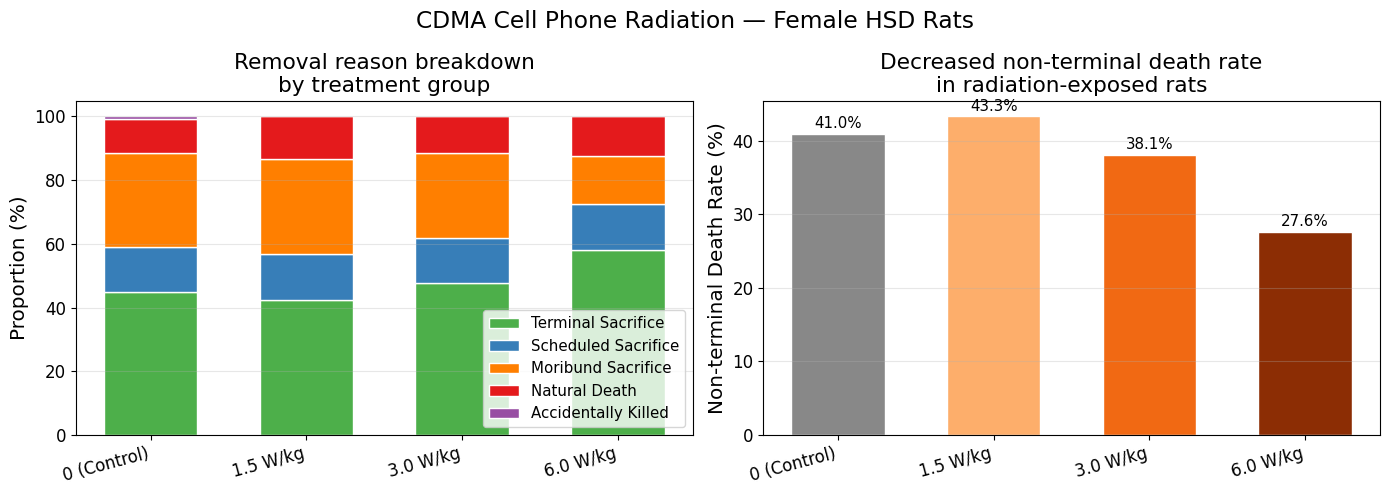

In [10]:
dose_colors_list   = ["#888888", "#FDAE6B", "#F16913", "#8C2D04"]
dose_bar_labels_list = ["0 (Control)", "1.5 W/kg", "3.0 W/kg", "6.0 W/kg"]
doses_ordered      = [0, 1.5, 3.0, 6.0]

reason_order   = ["Terminal Sacrifice", "Scheduled Sacrifice", "Moribund Sacrifice", "Natural Death",
                  "Accidentally Killed"]
reason_palette = ["#4daf4a", "#377eb8", "#ff7f00", "#e41a1c", "#984ea3"]

# Proportion table
reason_grp = df.groupby(["Dose", "Removal Reason"]).size().unstack(fill_value=0)
for r in reason_order:
    if r not in reason_grp.columns:
        reason_grp[r] = 0
cols = [c for c in reason_order if c in reason_grp.columns] + \
       [c for c in reason_grp.columns if c not in reason_order]
reason_pct = reason_grp[cols].div(reason_grp[cols].sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: stacked removal-reason bar ──
x = np.arange(len(doses_ordered))
bottoms = np.zeros(len(doses_ordered))
for col, color in zip(cols, reason_palette):
    vals = np.array([reason_pct.loc[d, col] if d in reason_pct.index else 0 for d in doses_ordered])
    ax1.bar(x, vals, bottom=bottoms, color=color, label=col, edgecolor="white", width=0.6)
    bottoms += vals
ax1.set_xticks(x)
ax1.set_xticklabels(dose_bar_labels_list, rotation=15, ha="right", fontsize=12)
ax1.set_ylabel("Proportion (%)", fontsize=14.4)
ax1.set_title("Removal reason breakdown\nby treatment group", fontsize=15.6)
ax1.legend(loc="lower right", fontsize=10.8)
ax1.set_ylim(0, 105)
ax1.grid(axis="y", alpha=0.3)
ax1.tick_params(axis='both', labelsize=12)

# ── Right: non-terminal death rate ──
non_terminal = ["Moribund Sacrifice", "Natural Death", "Accidentally Killed"]
for i, (dose, color, label) in enumerate(zip(doses_ordered, dose_colors_list, dose_bar_labels_list)):
    grp = df[df["Dose"] == dose]
    rate = 100 * grp["Removal Reason"].isin(non_terminal).mean()
    ax2.bar(i, rate, color=color, edgecolor="white", width=0.6)
    ax2.text(i, rate + 0.4, f"{rate:.1f}%", ha="center", va="bottom", fontsize=10.8)
ax2.set_xticks(range(len(doses_ordered)))
ax2.set_xticklabels(dose_bar_labels_list, rotation=15, ha="right", fontsize=12)
ax2.set_ylabel("Non-terminal Death Rate (%)", fontsize=14.4)
ax2.set_title("Decreased non-terminal death rate\nin radiation-exposed rats", fontsize=15.6)
ax2.grid(axis="y", alpha=0.3)
ax2.tick_params(axis='both', labelsize=12)

plt.suptitle("CDMA Cell Phone Radiation — Female HSD Rats", fontsize=16.8)
plt.tight_layout()
plt.show()

## 10. Odds Ratios — Dose Effect on Mortality

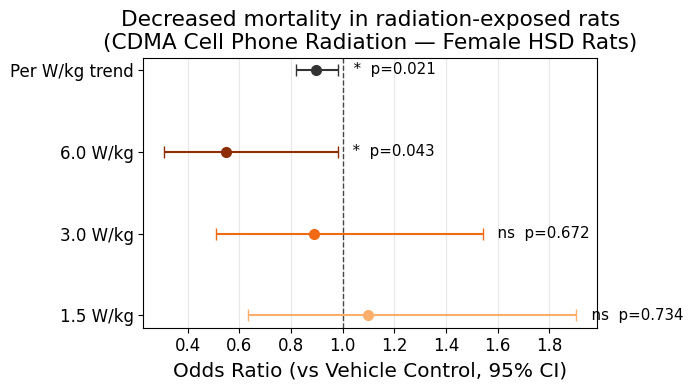

In [11]:
# Logistic regression: mortality (event=1) ~ dose group vs control (binary)
# + continuous dose-trend model
ctrl_grp = df[df["Dose"] == 0]
exposed_doses = [1.5, 3.0, 6.0]
exposed_colors = ["#FDAE6B", "#F16913", "#8C2D04"]
exposed_labels = ["1.5 W/kg", "3.0 W/kg", "6.0 W/kg"]

rows = []
for dose, color, label in zip(exposed_doses, exposed_colors, exposed_labels):
    combined = pd.concat([ctrl_grp, df[df["Dose"] == dose]]).copy()
    combined["exposed"] = (combined["Dose"] == dose).astype(int)
    X = sm.add_constant(combined["exposed"])
    m = sm.Logit(combined["event"], X).fit(disp=0)
    ci = m.conf_int().loc["exposed"]
    rows.append({
        "label": label, "color": color,
        "or": np.exp(m.params["exposed"]),
        "lo": np.exp(ci[0]), "hi": np.exp(ci[1]),
        "p": m.pvalues["exposed"],
    })

# Continuous dose-trend model
X_cont = sm.add_constant(df["Dose"])
m_cont = sm.Logit(df["event"], X_cont).fit(disp=0)
ci_cont = m_cont.conf_int().loc["Dose"]
rows.append({
    "label": "Per W/kg trend", "color": "#333333",
    "or": np.exp(m_cont.params["Dose"]),
    "lo": np.exp(ci_cont[0]), "hi": np.exp(ci_cont[1]),
    "p": m_cont.pvalues["Dose"],
})

fig, ax = plt.subplots(figsize=(7, 4))
y_pos = np.arange(len(rows))
for i, r in enumerate(rows):
    or_, lo, hi, p = r["or"], r["lo"], r["hi"], r["p"]
    ax.errorbar(or_, i, xerr=[[or_ - lo], [hi - or_]], fmt="o",
                color=r["color"], markersize=7, capsize=4, linewidth=1.5, zorder=3)
    star = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ax.text(hi + 0.02, i, f"  {star}  p={p:.3f}", va="center", fontsize=10.8)

ax.axvline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels([r["label"] for r in rows], fontsize=12)
ax.set_xlabel("Odds Ratio (vs Vehicle Control, 95% CI)", fontsize=14.4)
ax.set_title("Decreased mortality in radiation-exposed rats\n(CDMA Cell Phone Radiation — Female HSD Rats)", fontsize=15.6)
ax.grid(axis="x", alpha=0.3)
ax.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.show()

## 11. Load Pathology Data & Build Per-Animal Pathology Indicators

Each pathology file lists only animals that **had** a given lesion. We merge with the full survival roster to create binary indicators (1 = pathology present, 0 = not found) for every animal.

In [12]:
DATA = Path("../data/TR-595_Technical_Report_Pathology_Tables_and_Curves")

def load_xls_path(filename):
    tables = pd.read_html(DATA / filename)
    return tables[1]

def load_pathology(filename, sex):
    df_p = load_xls_path(filename)
    df_p["Sex"] = sex
    return df_p

# ── Pooled survival (reuse female df already in memory, load male) ──
surv_f = df.copy()
surv_f["Sex"] = "Female"

surv_m = load_xls_path("2010556_Male_Individual_Animal_Survival_Data.xls")
surv_m["Dose"] = surv_m["Treatment"].map(dose_map)
surv_m["event"] = (~surv_m["Removal Reason"].isin(["Terminal Sacrifice", "Scheduled Sacrifice"])).astype(int)
surv_m["Sex"] = "Male"

surv = pd.concat([surv_f, surv_m], ignore_index=True)

print(f"Total animals: {len(surv)} (Female: {(surv.Sex=='Female').sum()}, Male: {(surv.Sex=='Male').sum()})")
print(f"\nAnimals per treatment group:")
display(surv.groupby("Dose").agg(n=("Animal Number","count"), events=("event","sum"),
                                  median_days=("Days on Study","median")).reset_index())

# ── Load pathology data ──
neo_f = load_pathology("2010556_Female_Individual_Animal_Neoplastic_Pathology_Data.xls", "Female")
neo_m = load_pathology("2010556_Male_Individual_Animal_Neoplastic_Pathology_Data.xls", "Male")
non_f = load_pathology("2010556_Female_Individual_Animal_Non_Neoplastic_Pathology_Data.xls", "Female")
non_m = load_pathology("2010556_Male_Individual_Animal_Non_Neoplastic_Pathology_Data.xls", "Male")

neo = pd.concat([neo_f, neo_m], ignore_index=True)
non = pd.concat([non_f, non_m], ignore_index=True)

neo["Pathology"] = neo["Organ"] + " — " + neo["Lesion Name"]
non["Pathology"] = non["Organ"] + " — " + non["Lesion Name"]
neo["Type"] = "Neoplastic"
non["Type"] = "Non-Neoplastic"

path_all = pd.concat([neo, non], ignore_index=True)

# ── Exclude scheduled-sacrifice animals (interim sacrifice at week 14) ──
scheduled = surv[surv["Removal Reason"] == "Scheduled Sacrifice"]["Animal Number"].unique()
surv_main = surv[surv["Removal Reason"] != "Scheduled Sacrifice"].copy()

print(f"\nNeoplastic pathology types: {neo['Pathology'].nunique()}")
print(f"Non-neoplastic pathology types: {non['Pathology'].nunique()}")
print(f"Total pathology records: {len(path_all)}")
print(f"\nExcluding {len(scheduled)} scheduled-sacrifice animals. Remaining for analysis: {len(surv_main)}")

Total animals: 839 (Female: 419, Male: 420)

Animals per treatment group:


,Dose,n,events,median_days
0,0.0,210,108,662.0
1,1.5,209,92,706.0
2,3.0,210,75,730.0
3,6.0,210,76,720.0



Neoplastic pathology types: 214
Non-neoplastic pathology types: 356
Total pathology records: 20958

Excluding 120 scheduled-sacrifice animals. Remaining for analysis: 719


## 11b. Hazard Ratios — Pairwise and Dose Trend (Cox Proportional Hazards)

The hazard ratio (HR) from a Cox model quantifies the relative risk of death at any given time point. HR < 1 means the group has lower mortality risk (lives longer); HR = 0.5 means half the instantaneous death risk.

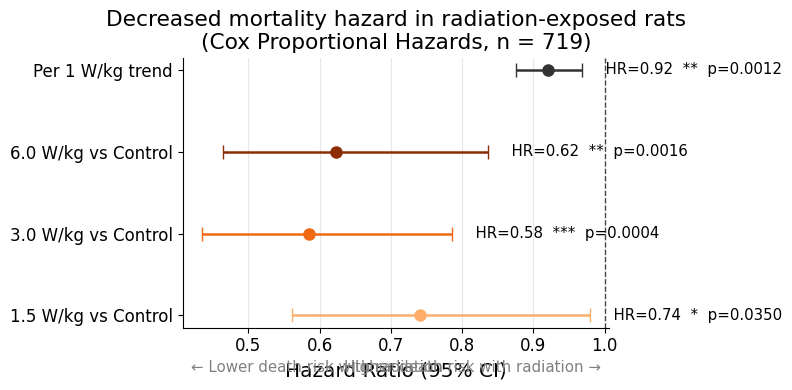

In [13]:
from lifelines import CoxPHFitter
import seaborn as sns

surv_cox = surv_main.copy()
rat_dose_colors = {0: "#888888", 1.5: "#FDAE6B", 3.0: "#F16913", 6.0: "#8C2D04"}

# Pairwise HRs vs control
rows = []
for d2 in [1.5, 3.0, 6.0]:
    pair = surv_cox[surv_cox.Dose.isin([0, d2])].copy()
    pair["exposed"] = (pair["Dose"] == d2).astype(int)
    cph = CoxPHFitter()
    cph.fit(pair[["Days on Study", "event", "exposed"]], duration_col="Days on Study", event_col="event")
    hr = np.exp(cph.params_["exposed"])
    ci = np.exp(cph.confidence_intervals_.values[0])
    p = cph.summary["p"]["exposed"]
    rows.append({"label": f"{d2} W/kg vs Control", "hr": hr, "lo": ci[0], "hi": ci[1], "p": p,
                 "color": rat_dose_colors[d2]})

# Dose trend
cph_trend = CoxPHFitter()
cph_trend.fit(surv_cox[["Days on Study", "event", "Dose"]], duration_col="Days on Study", event_col="event")
hr_t = np.exp(cph_trend.params_["Dose"])
ci_t = np.exp(cph_trend.confidence_intervals_.values[0])
p_t = cph_trend.summary["p"]["Dose"]
rows.append({"label": "Per 1 W/kg trend", "hr": hr_t, "lo": ci_t[0], "hi": ci_t[1], "p": p_t,
             "color": "#333333"})

fig, ax = plt.subplots(figsize=(8, 4))
for i, r in enumerate(rows):
    ax.errorbar(r["hr"], i, xerr=[[r["hr"] - r["lo"]], [r["hi"] - r["hr"]]], fmt="o",
                color=r["color"], markersize=8, capsize=5, linewidth=1.8, zorder=3)
    star = "***" if r["p"] < 0.001 else "**" if r["p"] < 0.01 else "*" if r["p"] < 0.05 else "ns"
    ax.text(r["hi"] + 0.02, i, f'  HR={r["hr"]:.2f}  {star}  p={r["p"]:.4f}', va="center", fontsize=10.8)

ax.axvline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax.set_yticks(range(len(rows)))
ax.set_yticklabels([r["label"] for r in rows], fontsize=12)
ax.set_xlabel("Hazard Ratio (95% CI)", fontsize=14.4)
ax.set_title("Decreased mortality hazard in radiation-exposed rats\n(Cox Proportional Hazards, n = 719)", fontsize=15.6)
ax.tick_params(axis="both", labelsize=12)
ax.grid(axis="x", alpha=0.3)
ax.text(0.02, -0.12, "← Lower death risk with radiation", transform=ax.transAxes, ha="left", va="top", fontsize=10.8, color="gray")
ax.text(0.98, -0.12, "Higher death risk with radiation →", transform=ax.transAxes, ha="right", va="top", fontsize=10.8, color="gray")
plt.tight_layout()
sns.despine()
plt.show()

## 12. Logistic Regression: Dose Effect on Each Pathology

For each pathology with ≥15 affected animals, we fit three logistic regression models:

| Model | Formula | Purpose |
|-------|---------|---------|
| 1 | `pathology ~ Dose` | Unadjusted dose-response |
| 2 | `pathology ~ Dose + Sex` | Adjusted for sex |
| 3 | `pathology ~ Dose + Sex + Days_on_Study` | Adjusted for sex + survival time |

Model 3 directly addresses survival confounding: if dose is only significant in Models 1–2 but not Model 3, the effect is explained by differential survival rather than a direct radiation effect.

Dose is treated as a continuous variable (0, 1.5, 3.0, 6.0 W/kg) to test for a linear dose-response trend.

In [14]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
from src.plots import run_pathology_regression, format_results, plot_forest, plot_prevalence_bars

DOSE_VALS = [0, 1.5, 3.0, 6.0]
DOSE_COLORS = ["#888888", "#FDAE6B", "#F16913", "#8C2D04"]
DOSE_BAR_LABELS = ["0 (Control)", "1.5 W/kg", "3.0 W/kg", "6.0 W/kg"]

In [15]:
# ── Run for all pathologies with ≥15 affected animals ──
MIN_AFFECTED = 15
path_counts = path_all.groupby(["Pathology", "Type"])["Animal Number"].nunique().reset_index(name="n_affected")
path_eligible = path_counts[path_counts["n_affected"] >= MIN_AFFECTED]

print(f"Pathologies with ≥{MIN_AFFECTED} affected animals: {len(path_eligible)} "
      f"({(path_eligible.Type=='Neoplastic').sum()} neoplastic, "
      f"{(path_eligible.Type=='Non-Neoplastic').sum()} non-neoplastic)")

all_results = []
for _, row in path_eligible.iterrows():
    res = run_pathology_regression(row["Pathology"], row["Type"], surv_main, path_all, DOSE_VALS)
    if res:
        all_results.append(res)

results_df = pd.DataFrame(all_results)
print(f"Successfully modeled: {len(results_df)} pathologies")

Pathologies with ≥15 affected animals: 131 (20 neoplastic, 111 non-neoplastic)


Successfully modeled: 122 pathologies


## 13. Results — Neoplastic Pathologies

Sorted by Model 1 (unadjusted) p-value. Key columns:
- **OR** = Odds Ratio per 1 W/kg increase in dose
- **p** = p-value for the dose coefficient
- Compare M1 vs M3: if M1 is significant but M3 is not, the effect is likely confounded by survival

In [16]:
neo_results = format_results(results_df, "Neoplastic")
print(f"Neoplastic pathologies analyzed: {len(neo_results)}")
display(neo_results.style.apply(
    lambda row: ["background: #ffffcc" if row["M1: p"] < 0.05 else "" for _ in row], axis=1
).format(precision=4))

Neoplastic pathologies analyzed: 18


,Pathology,N,Prev%,M1: OR,M1: p,M2: OR,M2: p,M3: OR,M3: p,M3: Days OR,M3: Days p
0,Heart — Schwannoma Malignant,16,2.2000,1.3510,0.0097,1.3540,0.0094,1.3590,0.0092,1.0018,0.5156
1,Liver — Hepatocellular Adenoma,18,2.5000,0.7930,0.0705,0.7920,0.0700,0.7600,0.0393,1.0126,0.0456
2,Mammary Gland — Adenocarcinoma,28,3.9000,0.8500,0.0941,0.8450,0.0870,0.8590,0.1292,0.9975,0.0825
3,Liver — Lymphoma Malignant,18,2.5000,1.1700,0.1318,1.1700,0.1318,1.1730,0.1265,0.9991,0.6396
4,Thyroid Gland — Carcinoma,17,2.4000,1.1360,0.2348,1.1360,0.2348,1.1220,0.2952,1.0077,0.1074
5,Lung — Lymphoma Malignant,19,2.6000,1.1130,0.2935,1.1130,0.2936,1.1180,0.2701,0.9976,0.1616
6,Pituitary Gland — Adenoma,242,33.7000,0.9650,0.3175,0.9630,0.3070,0.9410,0.1114,1.0064,0.0000
7,Spleen — Lymphoma Malignant,18,2.5000,1.0960,0.3790,1.0960,0.3791,1.1050,0.3383,0.9975,0.1453
8,Thyroid Gland — Adenoma,74,10.3000,1.0390,0.4851,1.0390,0.4817,1.0330,0.5676,1.0049,0.0064
9,Lymph Node — Lymphoma Malignant,18,2.5000,1.0610,0.5752,1.0610,0.5754,1.0670,0.5406,0.9983,0.3691


## 14. Results — Non-Neoplastic Pathologies

In [17]:
non_results = format_results(results_df, "Non-Neoplastic")
print(f"Non-neoplastic pathologies analyzed: {len(non_results)}")
display(non_results.style.apply(
    lambda row: ["background: #ffffcc" if row["M1: p"] < 0.05 else "" for _ in row], axis=1
).format(precision=4))

Non-neoplastic pathologies analyzed: 104


,Pathology,N,Prev%,M1: OR,M1: p,M2: OR,M2: p,M3: OR,M3: p,M3: Days OR,M3: Days p
0,Bone — Fibrous Osteodystrophy,87,12.1000,0.6510,0.0000,0.6090,0.0000,0.6110,0.0000,0.9993,0.5868
1,Pancreas — Inflammation,114,15.9000,0.7170,0.0000,0.6810,0.0000,0.6660,0.0000,1.0041,0.0051
2,"Stomach, Glandular — Mineral",47,6.5000,0.5260,0.0000,0.4960,0.0000,0.5070,0.0000,0.9974,0.1085
3,Aorta — Mineral,46,6.4000,0.5690,0.0000,0.5430,0.0000,0.5520,0.0000,0.9974,0.0985
4,Intestine Large — Inflammation,51,7.1000,0.6340,0.0000,0.6140,0.0000,0.6120,0.0000,1.0005,0.7719
5,Mesentery — Inflammation,73,10.2000,0.7240,0.0000,0.7070,0.0000,0.7070,0.0000,1.0001,0.9532
6,Thymus — Hemorrhage,40,5.6000,1.3920,0.0000,1.3950,0.0000,1.4160,0.0000,0.9939,0.0000
7,Mesentery — Mineral,28,3.9000,0.3980,0.0000,0.3780,0.0000,0.3950,0.0000,0.9967,0.0805
8,Heart — Mineral,35,4.9000,0.5550,0.0000,0.5370,0.0000,0.5400,0.0000,0.9995,0.7813
9,Parathyroid Gland — Hyperplasia,146,20.3000,0.8190,0.0000,0.7840,0.0000,0.7770,0.0000,1.0038,0.0028


## 15. Summary: Confounding Analysis

How many pathologies show a significant dose effect (p < 0.05) in each model?  
If the count drops substantially from M1 → M3, survival confounding is a major factor.

In [18]:
summary = []
for ptype in ["Neoplastic", "Non-Neoplastic"]:
    subset = results_df[results_df["type"] == ptype]
    summary.append({
        "Type": ptype,
        "Total Analyzed": len(subset),
        "M1 sig (p<0.05)": (subset["m1_dose_p"] < 0.05).sum(),
        "M2 sig (p<0.05)": (subset["m2_dose_p"] < 0.05).sum(),
        "M3 sig (p<0.05)": (subset["m3_dose_p"] < 0.05).sum(),
    })

summary_df = pd.DataFrame(summary)
display(summary_df)

# Pathologies where M1 significant but M3 not — evidence of survival confounding
confounded = results_df[(results_df["m1_dose_p"] < 0.05) & (results_df["m3_dose_p"] >= 0.05)]
persistent = results_df[(results_df["m1_dose_p"] < 0.05) & (results_df["m3_dose_p"] < 0.05)]

print(f"\n{'='*80}")
print(f"Pathologies where dose is significant UNADJUSTED but NOT after age adjustment")
print(f"(i.e., confounded by survival): {len(confounded)}")
print(f"{'='*80}")
for _, row in confounded.sort_values("m1_dose_p").iterrows():
    direction = "↑" if row["m1_dose_or"] > 1 else "↓"
    print(f"  {direction} {row['type']:15s} | {row['pathology']:45s} | M1 OR={row['m1_dose_or']:.3f} p={row['m1_dose_p']:.4f} → M3 OR={row['m3_dose_or']:.3f} p={row['m3_dose_p']:.4f}")

print(f"\n{'='*80}")
print(f"Pathologies where dose remains significant AFTER age adjustment")
print(f"(i.e., likely a real radiation effect): {len(persistent)}")
print(f"{'='*80}")
for _, row in persistent.sort_values("m3_dose_p").iterrows():
    direction = "↑" if row["m3_dose_or"] > 1 else "↓"
    print(f"  {direction} {row['type']:15s} | {row['pathology']:45s} | M1 OR={row['m1_dose_or']:.3f} p={row['m1_dose_p']:.4f} → M3 OR={row['m3_dose_or']:.3f} p={row['m3_dose_p']:.4f}")

,Type,Total Analyzed,M1 sig (p<0.05),M2 sig (p<0.05),M3 sig (p<0.05)
0,Neoplastic,18,1,1,2
1,Non-Neoplastic,104,32,32,34



Pathologies where dose is significant UNADJUSTED but NOT after age adjustment
(i.e., confounded by survival): 0

Pathologies where dose remains significant AFTER age adjustment
(i.e., likely a real radiation effect): 33
  ↓ Non-Neoplastic  | Bone — Fibrous Osteodystrophy                 | M1 OR=0.651 p=0.0000 → M3 OR=0.611 p=0.0000
  ↓ Non-Neoplastic  | Pancreas — Inflammation                       | M1 OR=0.717 p=0.0000 → M3 OR=0.666 p=0.0000
  ↓ Non-Neoplastic  | Pancreas — Hyperplasia                        | M1 OR=0.845 p=0.0000 → M3 OR=0.757 p=0.0000
  ↓ Non-Neoplastic  | Stomach, Glandular — Mineral                  | M1 OR=0.526 p=0.0000 → M3 OR=0.507 p=0.0000
  ↓ Non-Neoplastic  | Aorta — Mineral                               | M1 OR=0.569 p=0.0000 → M3 OR=0.552 p=0.0000
  ↓ Non-Neoplastic  | Parathyroid Gland — Hyperplasia               | M1 OR=0.819 p=0.0000 → M3 OR=0.777 p=0.0000
  ↓ Non-Neoplastic  | Intestine Large — Inflammation                | M1 OR=0.634 p=0.0000 → M3

## 16. Forest Plots — Dose Odds Ratio per Pathology

Each point is the odds ratio for a 1 W/kg increase in dose, with 95% CI. Three models shown per pathology:
- **M1** (gray): Unadjusted
- **M2** (orange): Adjusted for sex
- **M3** (dark orange/brown): Adjusted for sex + age — the key model for answering the confounding question

OR = 1 (dashed line) means no effect. Circled points = p < 0.05.

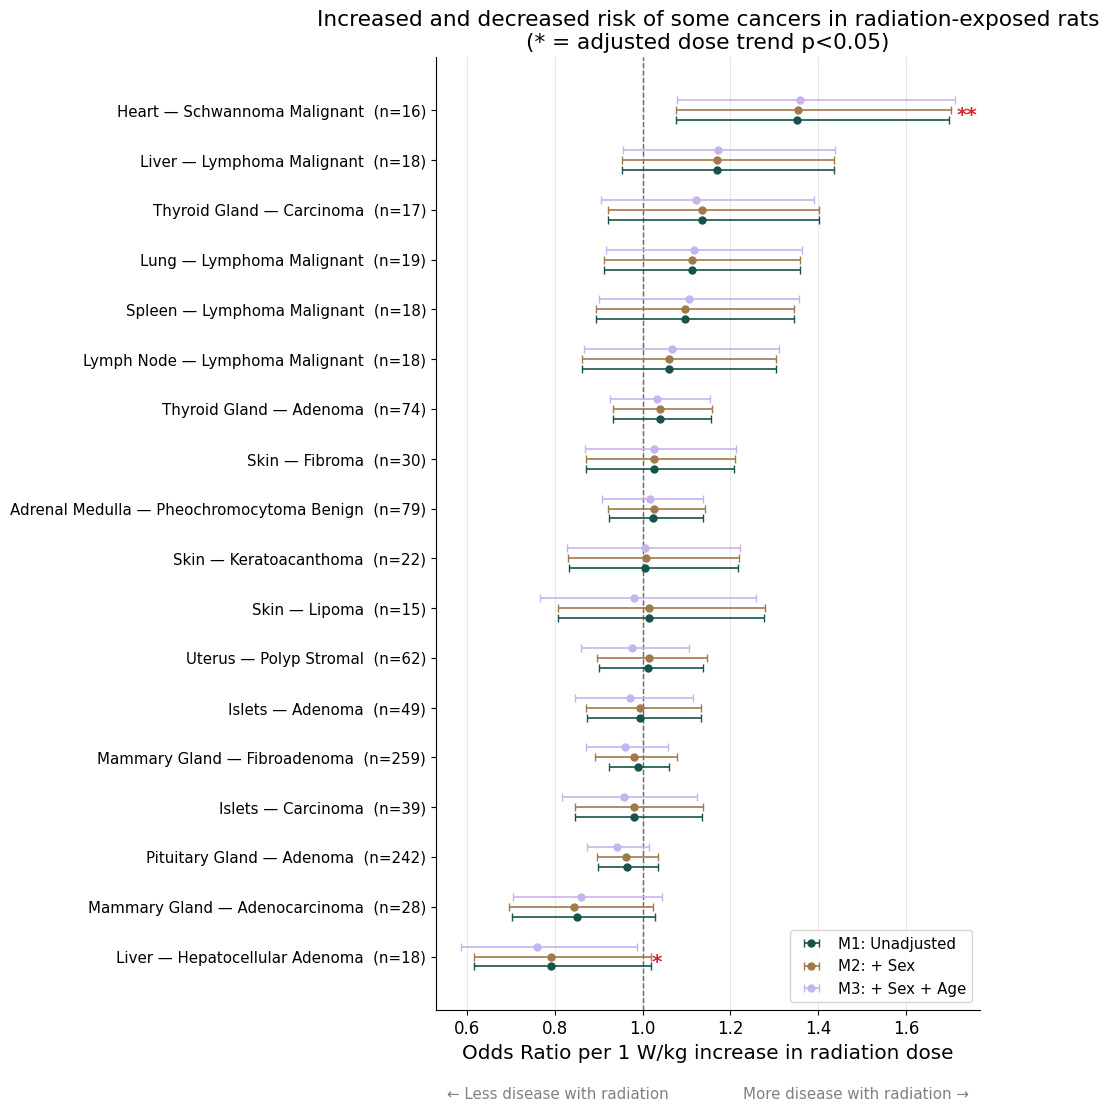

In [19]:
plot_forest(results_df, "Neoplastic", "Increased and decreased risk of some cancers in radiation-exposed rats")

## 17. Forest Plot — Non-Neoplastic Pathologies

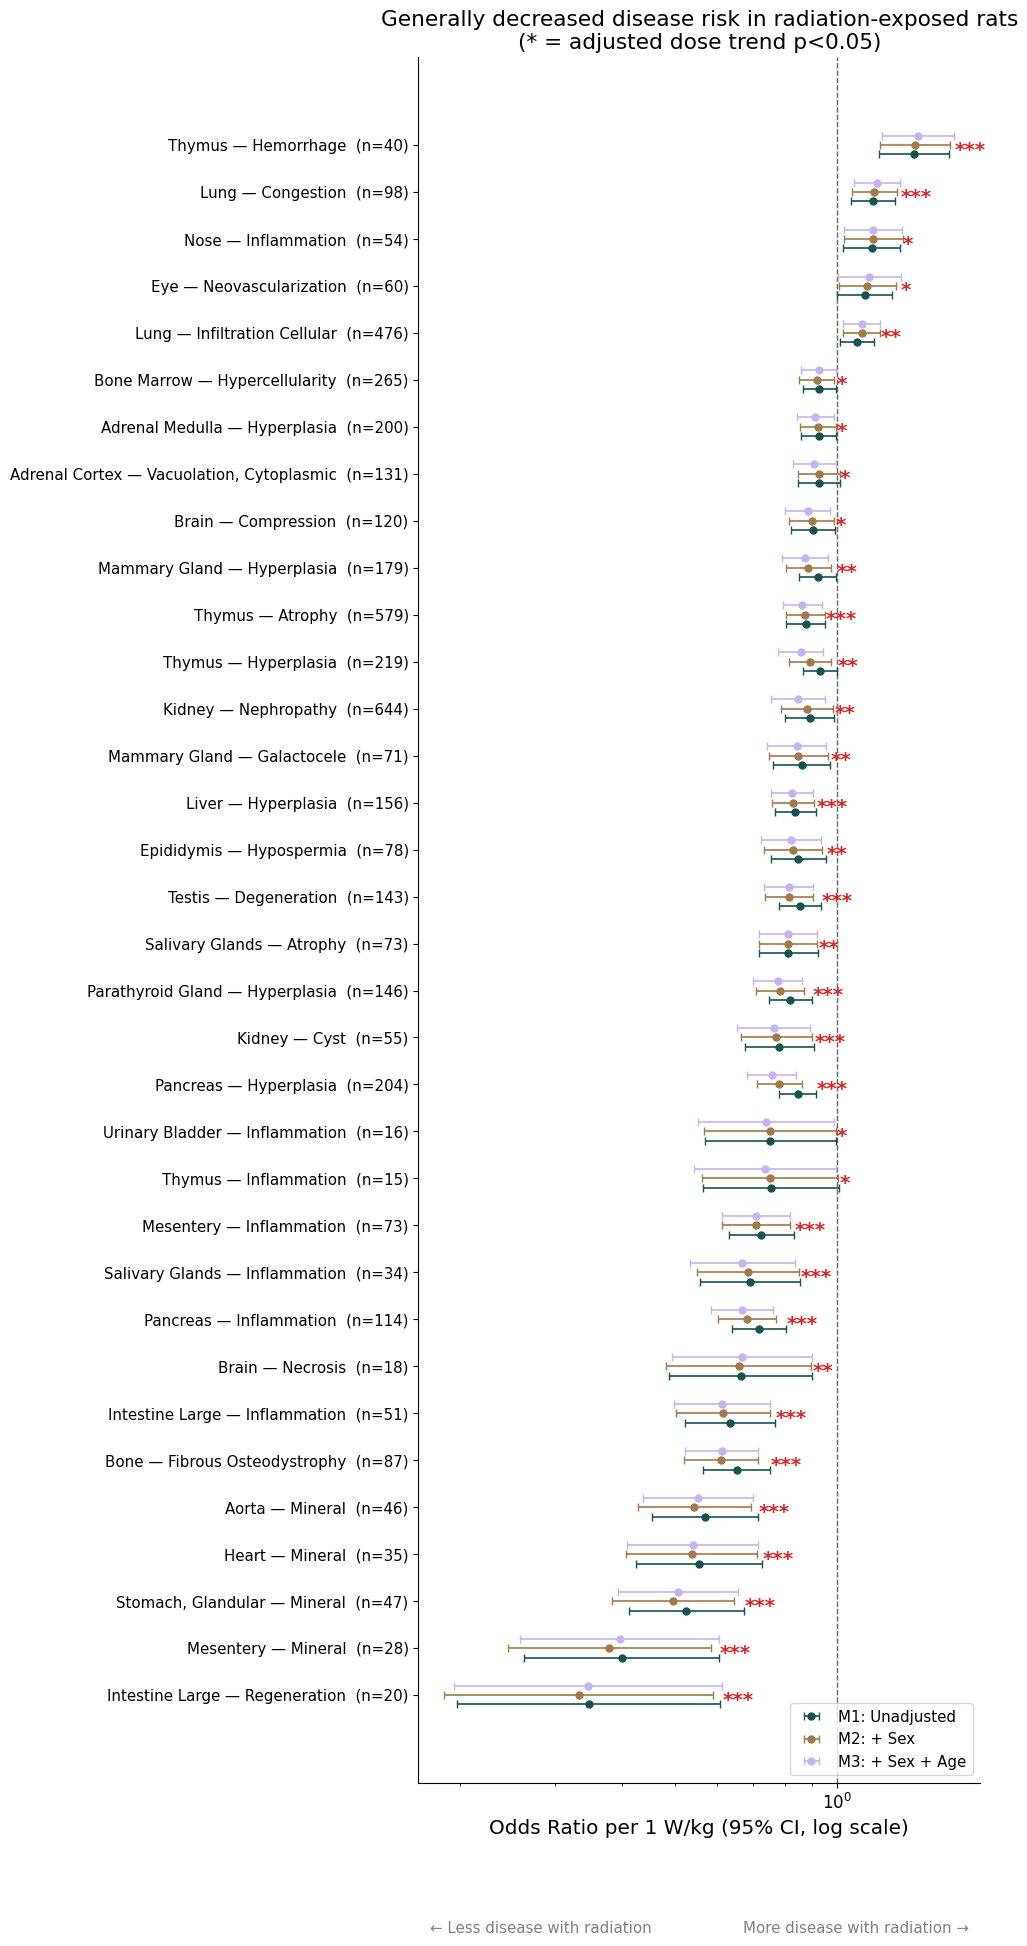

In [20]:
plot_forest(results_df, "Non-Neoplastic", "Generally decreased disease risk in radiation-exposed rats", significant_only=True)

## 18. Prevalence by Dose Group — Bar Plots

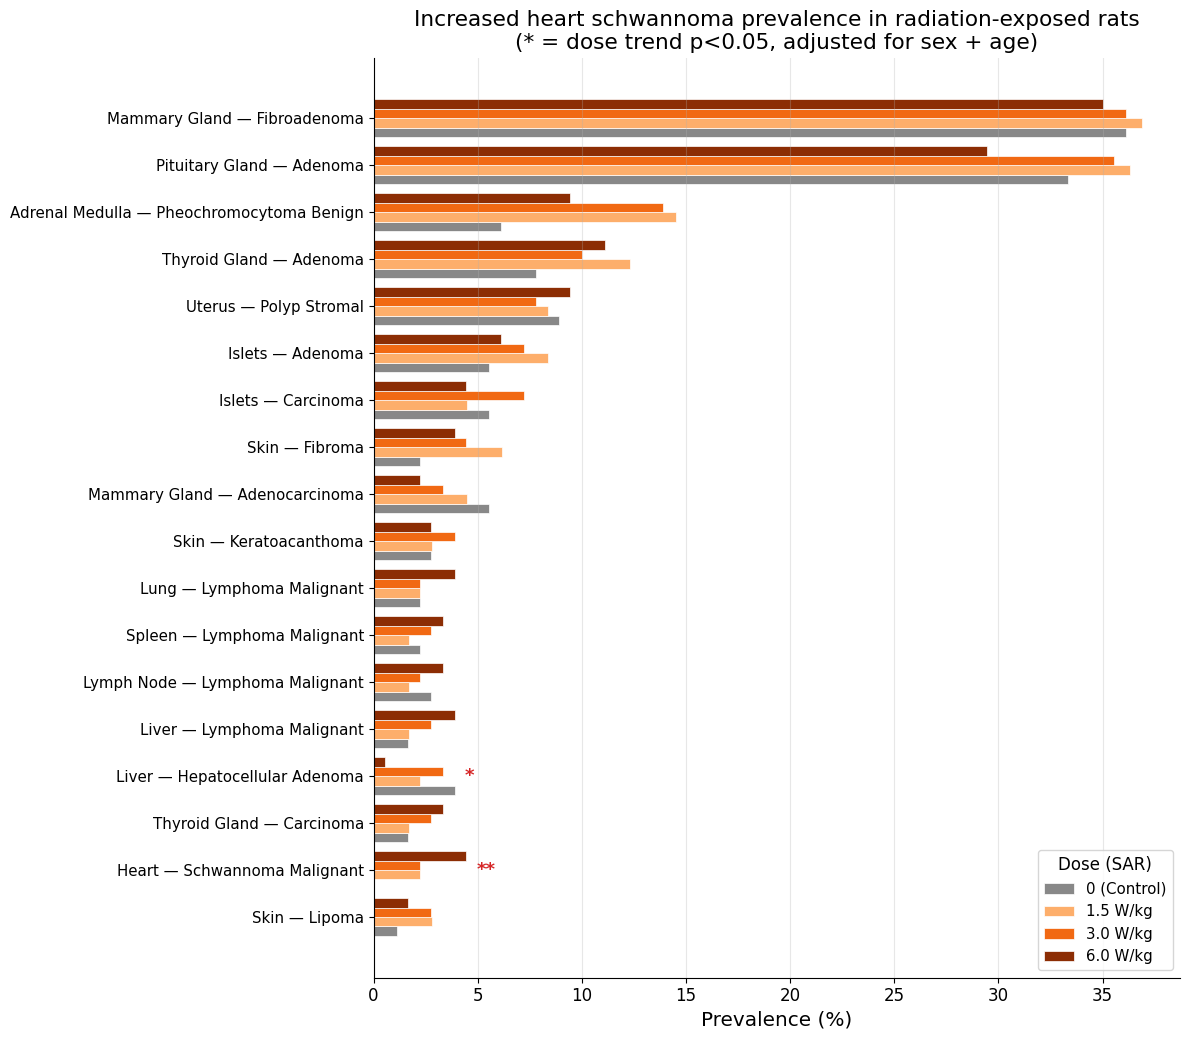

In [21]:
plot_prevalence_bars(results_df, "Neoplastic", "Increased heart schwannoma prevalence in radiation-exposed rats", DOSE_VALS, DOSE_COLORS, DOSE_BAR_LABELS)

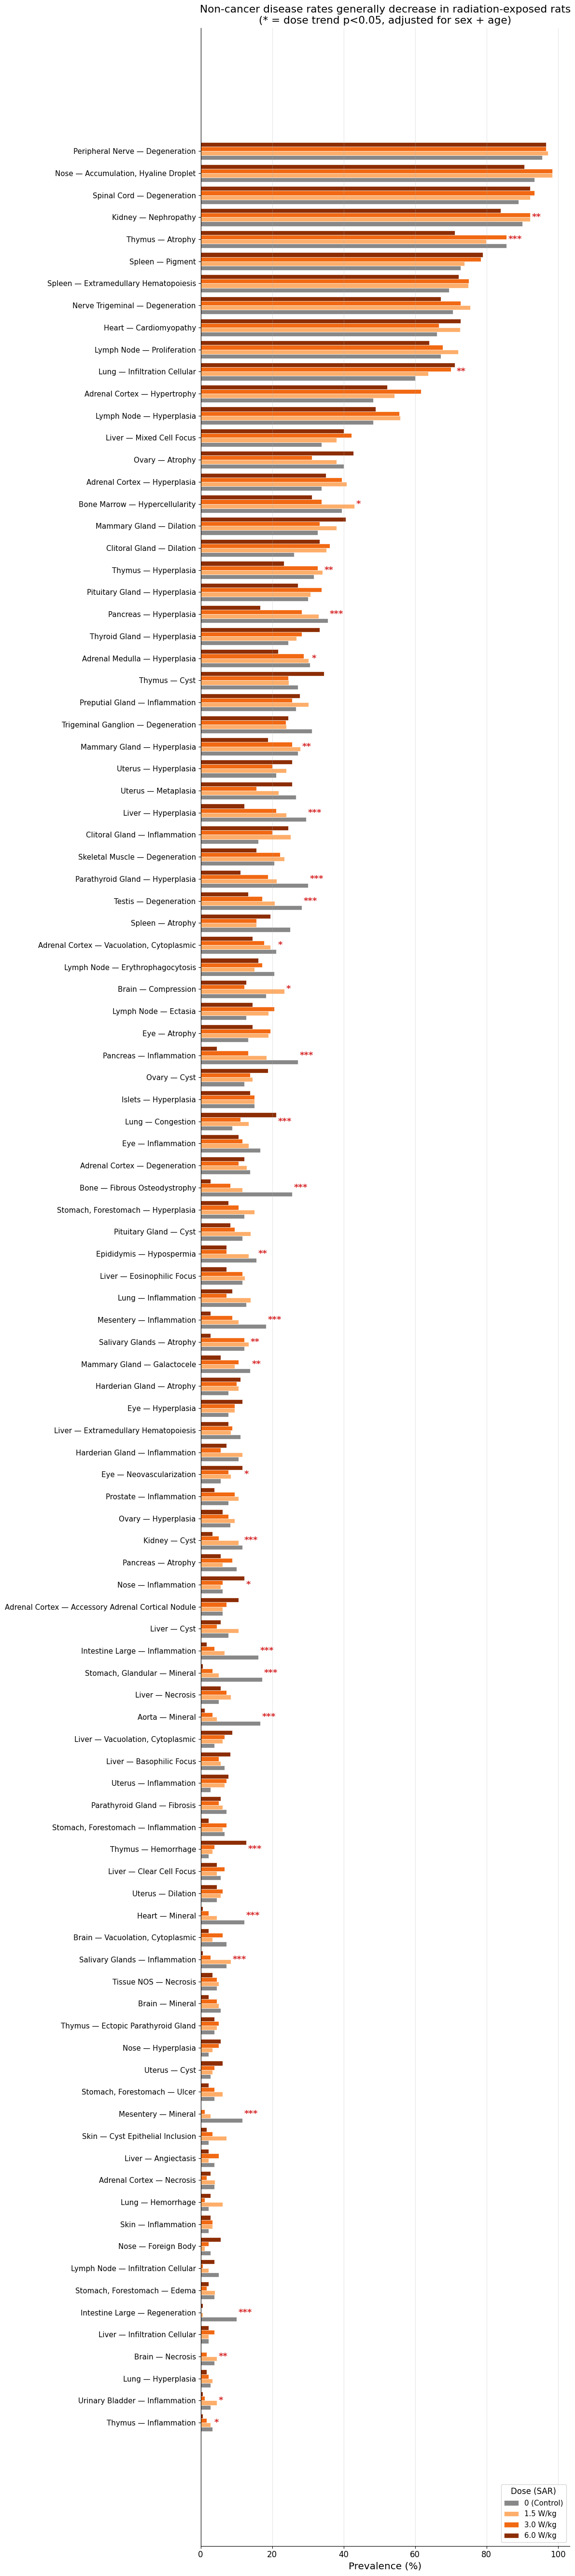

In [22]:
plot_prevalence_bars(results_df, "Non-Neoplastic", "Non-cancer disease rates generally decrease in radiation-exposed rats", DOSE_VALS, DOSE_COLORS, DOSE_BAR_LABELS)

## 19. Interpretation

**Key question:** Do CDMA-irradiated rats develop neoplasms at a greater rate, or is any apparent increase confounded by longer survival in irradiated groups?

The M1 → M3 comparison reveals whether a dose effect on pathology is genuine or an artifact of differential survival:
- **Confounded:** significant in M1 (unadjusted) but not in M3 (age-adjusted) — longer survival explains the higher tumor rate, not radiation
- **Persistent:** significant in both M1 and M3 — the dose effect is robust to survival adjustment and more likely a true radiation effect